In [62]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse

from convolution_as_MPO import construct_convolution_MPO

import importlib
import sys
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Chebyshev')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/TCI')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Correlation_function')
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Chebyshev")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/TCI")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Correlation_function")


import ED_Cs_Lsites as ED
import TCI_singlesite as TCI_single
import TCI_Lsite_accumulative_v1 as TCI_multi
import tensor_cross_interpolation as tci
import MPS 
import Chebyshev as Cheby
import peak_to_MPS as peakMPS

importlib.reload(ED)
importlib.reload(TCI_single)
importlib.reload(TCI_multi)
importlib.reload(MPS)
importlib.reload(Cheby)
importlib.reload(peakMPS)

<module 'peak_to_MPS' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Noisy/peak_to_MPS.py'>

## TCI algorithm on noisy data

In [63]:
# define Hamiltonian terms
L = 11
n = 11
dt = 1e-2
models = ['J = 1, g = 2 , Ising Model Ham. = H','J =1 g = 2 Ham. = H - k*Hzz', 'J = 1 g = 0.5, Ham. = H - h * Hxx', 'J = 1 g = 0.5, Ham. = H - k*Hzz - h*Hxx']
threshold = 30
N = 2**n
D = L
g_par = 0.1


In [64]:
# Generate Hamiltonian
Hlist = [ED.gen_Ham(L = L, model = 0), ED.gen_Ham(L = L, model = 2)]

In [65]:
Cs_theo = ED.correlator(H= Hlist[0], L = L, dt = dt,  n = n)
print(Cs_theo.shape)

for i in range(Cs_theo.shape[0]):
    for k in range(Cs_theo.shape[1]):
        if Cs_theo.real[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = 1. + 1j* Cs_theo.imag[i,k]
        if Cs_theo.imag[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = Cs_theo.real[i,k] + 1j

Expectation value $\bra{\psi_0} X_{L/2} \ket{psi_0}$=  -4.1023213235685766e-16
(11, 2048)
i,k: ( 5 , 0 ),  (1.0000000000000042+0j)


In [66]:
N_shots = 2**13 #8192 rough estimation by Bernhard
# clip to avoid tiny negative values from rounding
std_real = np.sqrt(np.clip(1 - Cs_theo.real**2, 0, None)) / np.sqrt(N_shots)
std_imag = np.sqrt(np.clip(1 - Cs_theo.imag**2, 0, None)) / np.sqrt(N_shots)

np.random.seed(0)  # optional
Cs_noise_real = np.random.normal(loc=0.0, scale=std_real)
Cs_noise_imag = np.random.normal(loc=0.0, scale=std_imag)

print(Cs_noise_real[0])

Cs_noise = Cs_theo + Cs_noise_real + 1j * Cs_noise_imag
print("shapes:", Cs_theo.shape, Cs_noise.shape)

[ 0.01948883  0.00442084  0.01081286 ...  0.00108669 -0.00514087
  0.01373149]
shapes: (11, 2048) (11, 2048)


In [67]:
diff_noisevstheo = Cs_theo-Cs_noise #should be difference between 2 matrices
err_max_noisevstheo = np.max(np.abs(diff_noisevstheo))/np.max(np.abs(Cs_theo))
print("Max error (noise vs theo): ", err_max_noisevstheo)
err_2_noisevstheo = np.linalg.norm(diff_noisevstheo)/np.linalg.norm(Cs_theo)
print("2-norm error (noise vs theo): ", err_2_noisevstheo)

Max error (noise vs theo):  0.05144266433827008
2-norm error (noise vs theo):  0.046755419203000366


In [68]:
# D = L #already defined above

func_vals_theo = Cs_theo.T #Cs is in the form (X,T)
func_vals_noise = Cs_noise.T

#first we define the function f(t)
# which returns the slice of func_vals along x for a specific time 
f_t_theo = lambda *t: Cs_theo.reshape((D,) + (2,) * n)[:,*t]
f_t_noise = lambda *t: Cs_noise.reshape((D,) + (2,) * n)[:,*t]

In [69]:
func_noise = TCI_multi.function(f_t_noise)
chi = 15

As, _, eval, err_2, err_max, func_interp_noise = TCI_multi.accumulative_tensor_cross_interpolation(func_noise,         # function to be interpolated
                                   func_vals_noise,    
                                   D,
                                   L=n,          # number of MPS tensors
                                   iters=chi-1)      # number of back-and-forth sweeps


err_max:  0.056245517018354285
err_2:  0.05400100027427108

repeated evaluations:  43750
unique evaluations 1410
unique + repeated:  45160
total evaluations:  45160



## Convolution part

In [70]:
# define some helper functions
def contract_MPS(Ms):
    vals = np.squeeze(Ms[0])
    for M in Ms[1:]:
        vals = np.einsum('ia, ajb -> ijb', vals, M)
        vals = vals.reshape(-1, M.shape[-1])
    vals = vals.reshape(-1)
    return vals

In [71]:

n = 11
xs = np.arange(2**n) / 2**n

In [72]:
#1. Peak of 5 entries
peak = [0.05, 0.2, 0.5, 0.2, 0.05]

In [73]:
#other peak shapes to try
peak = [0.01, 0.09, 0.4, 0.4, 0.09, 0.01]
# peak = [0.2, 0.2, 0.2, 0.2, 0.2]

[0.11827226 0.12394827 0.12788281 0.12989667 0.12989667 0.12788281
 0.12394827 0.11827226]


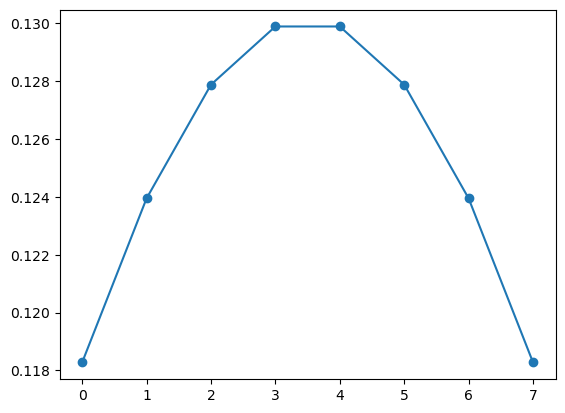

In [74]:
# 2. The Gaussian Peak Generator
def get_gaussian_peak(N, sigma_factor=6.0):
    """Generates a normalized Gaussian-shaped peak of N elements."""
    x = np.arange(N)
    mu = (N - 1) / 2.0
    sigma = max(N / sigma_factor, 1e-10)
    
    # Create the Gaussian shape
    peak = np.exp(-0.5 * ((x - mu) / sigma)**2)
    
    # Normalize it so the sum of squared amplitudes is 1 (quantum state normalization)
    peak = peak / np.sum(peak)
    
    return peak

peak = get_gaussian_peak(8, sigma_factor=1)
print(peak)

plt.plot(np.arange(len(peak)), peak, '-o')

In [75]:
#3. Savitzky-Golay filter
from scipy.signal import savgol_coeffs

def get_savgol_peak(window_length=9, polyorder=2):
    """
    Generates a Savitzky-Golay convolution kernel.
    window_length: The length of the filter window (must be a positive odd integer).
    polyorder: The order of the polynomial to preserve (2 for quadratic).
    """
    # savgol_coeffs returns exactly the 1D convolution array for SG smoothing
    peak = savgol_coeffs(window_length, polyorder)
    return peak

# Create a kernel that fits 2nd order polynomials over a window of 9 points
peak = get_savgol_peak(window_length=5, polyorder=3)

In [76]:
len_peak = len(peak)

full_peak = np.zeros(2**n)
for i in range(len_peak):
    idx = 2**(n-1) - len_peak//2 + i
    full_peak[idx] = peak[i]

In [77]:
Gs = peakMPS.build_peak_mps(n, peak)

# Print the resulting tensor shapes (Bond dimensions)
for i, T in enumerate(Gs):
    print(f"Site {i} tensor shape: {T.shape}")

Site 0 tensor shape: (1, 2, 5)
Site 1 tensor shape: (5, 2, 5)
Site 2 tensor shape: (5, 2, 5)
Site 3 tensor shape: (5, 2, 5)
Site 4 tensor shape: (5, 2, 5)
Site 5 tensor shape: (5, 2, 5)
Site 6 tensor shape: (5, 2, 5)
Site 7 tensor shape: (5, 2, 5)
Site 8 tensor shape: (5, 2, 5)
Site 9 tensor shape: (5, 2, 5)
Site 10 tensor shape: (5, 2, 1)


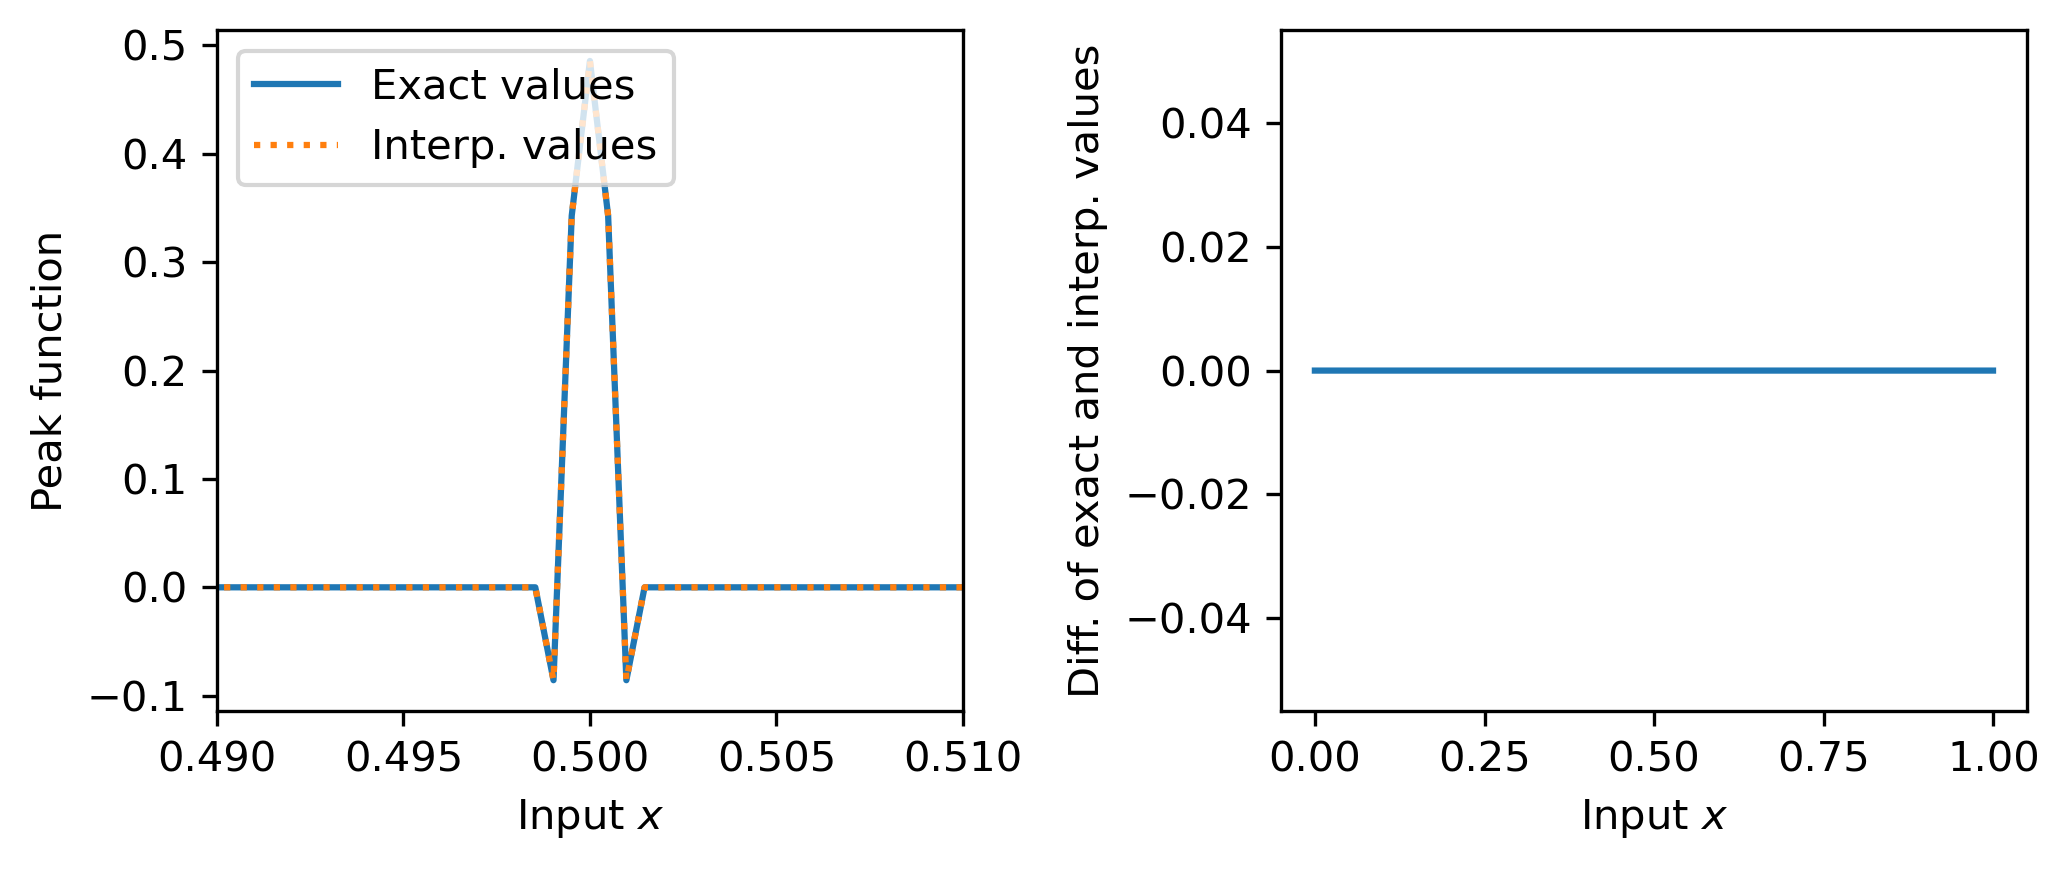

In [78]:
GMPS_vals = contract_MPS(Gs)

fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)

axs[0].plot(xs, full_peak, '-', label='Exact values')
axs[0].plot(xs, GMPS_vals, ':', label='Interp. values')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Peak function',
           xlim=(0.49, 0.51))
axs[0].legend(loc='upper left')

axs[1].plot(xs, full_peak - GMPS_vals, '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and interp. values')

plt.tight_layout()
plt.show()

In [79]:
for A in As:
    print(A.shape)

(11, 1, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 8)
(8, 2, 4)
(4, 2, 2)
(2, 2, 1)


In [80]:
def apply_MPO(MPO, MPS):
    Ms = []
    for W, M in zip(MPO, MPS):
        # Flatten any extra leading dimensions (e.g., (1, 1, 2, 8) becomes (1, 2, 8))
        if M.ndim > 3:
            M = M.reshape(-1, M.shape[-2], M.shape[-1])
            
        chilW, chirW, d, _ = W.shape
        chilM, _, chirM = M.shape
        
        # Apply the contraction
        new_M = np.einsum('abkj, cjd -> ackbd', W, M)
        
        # Reshape to standard 3-leg MPS format
        Ms.append(new_M.reshape(chilW * chilM, d, chirW * chirM))
        
    return Ms

In [81]:
Ws = construct_convolution_MPO(L, conv_MPS = Gs)
conv_As = apply_MPO(Ws, As)
conv_MPS_vals = MPS.interpolate_func(conv_As)

In [82]:
conv_func_interp = np.zeros_like(func_interp_noise)

for i in range(func_interp_noise.shape[1]):
    conv_func_interp[:, i] = np.convolve(func_interp_noise[:, i], full_peak, mode='same')

### Check whether convolution works as expected

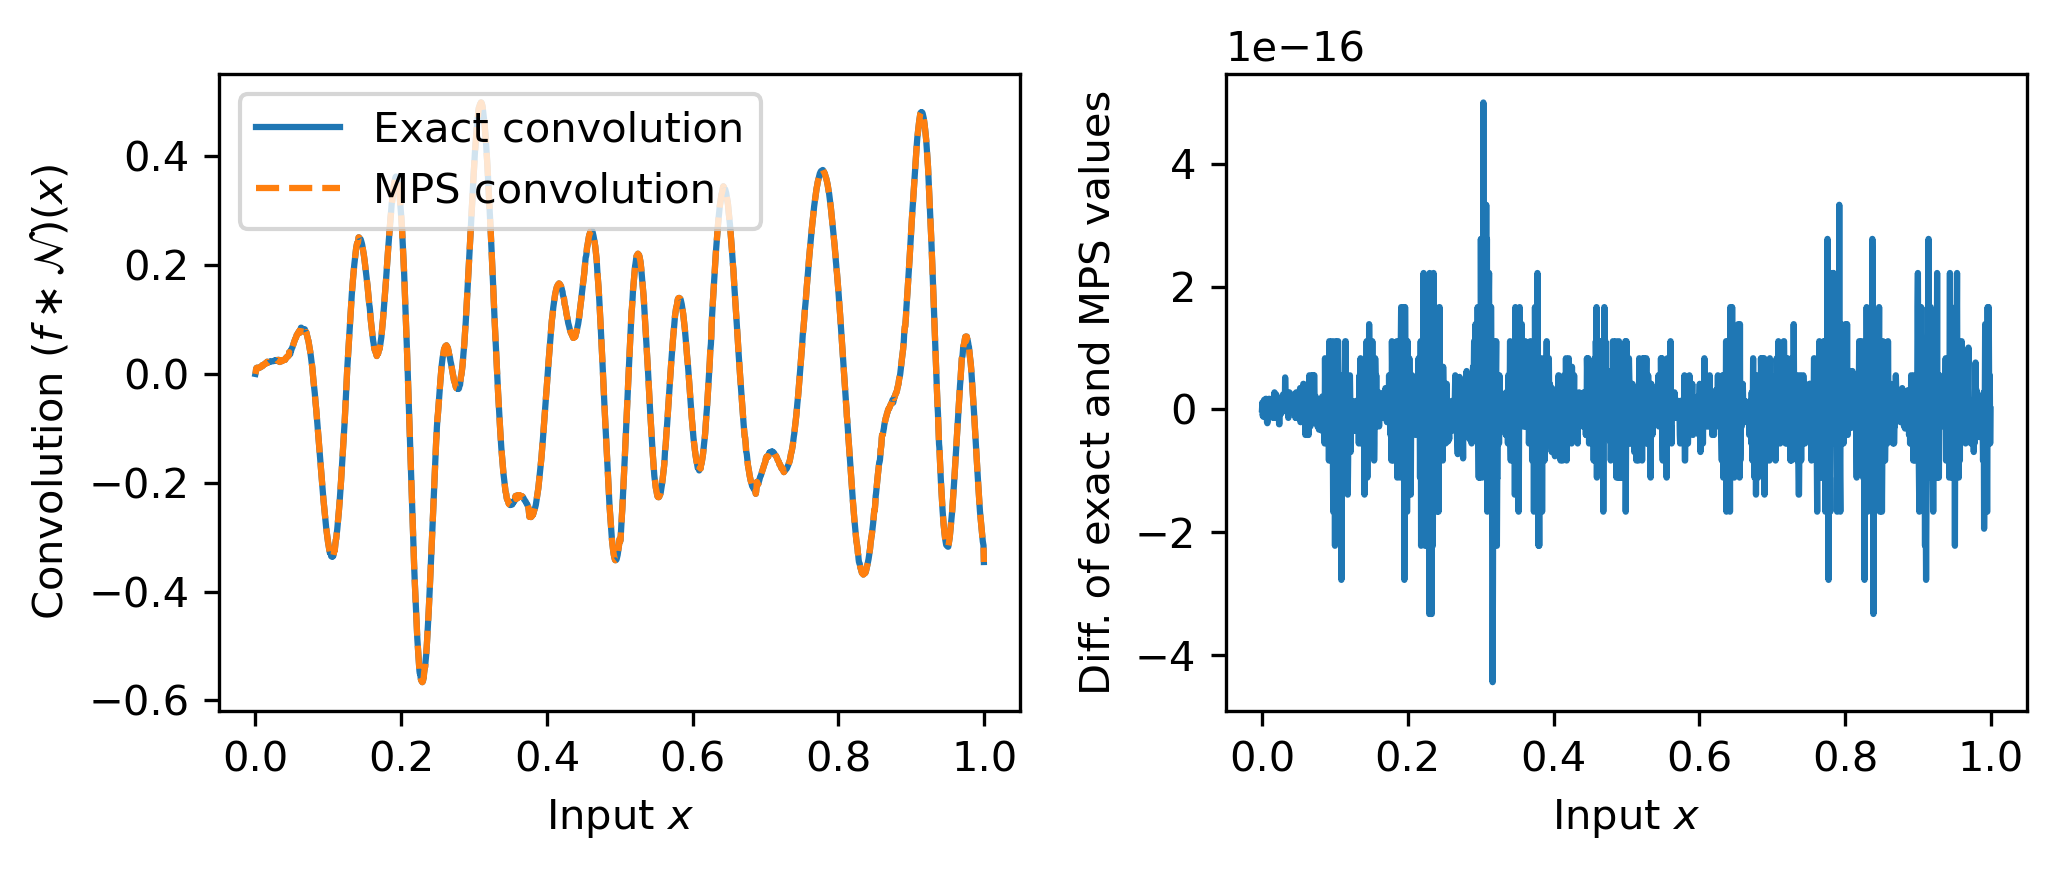

In [83]:
# Scegli l'indice spaziale/temporale da visualizzare nel plot
idx_to_plot = 1

# Plot comparison
fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)
axs[0].plot(xs, conv_func_interp[:, idx_to_plot], '-', label='Exact convolution')
axs[0].plot(xs, conv_MPS_vals[:, idx_to_plot], '--', label='MPS convolution')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
axs[0].legend(loc='upper left')

axs[1].plot(xs, conv_func_interp[:, idx_to_plot] - conv_MPS_vals[:, idx_to_plot], '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and MPS values')

plt.tight_layout()
plt.show()

In [84]:
conv_func_theo = np.zeros_like(func_vals_theo)

for i in range(func_vals_theo.shape[1]):
    conv_func_theo[:, i] = np.convolve(func_vals_theo[:, i], full_peak, mode='same')

In [85]:
err_max_theo, err_2_theo = MPS.errors(func_vals_theo, conv_func_theo, interpolate = False, truncate_array_1 = 100, truncate_array_2 = -100)
print("Max error (theo convolution vs theo): ", err_max_theo)
print("2-norm error (theo convolution vs theo): ", err_2_theo)

Max error (theo convolution vs theo):  0.03400259348064484
2-norm error (theo convolution vs theo):  0.034625674561536014


## Let's check if convolution reduces error :)

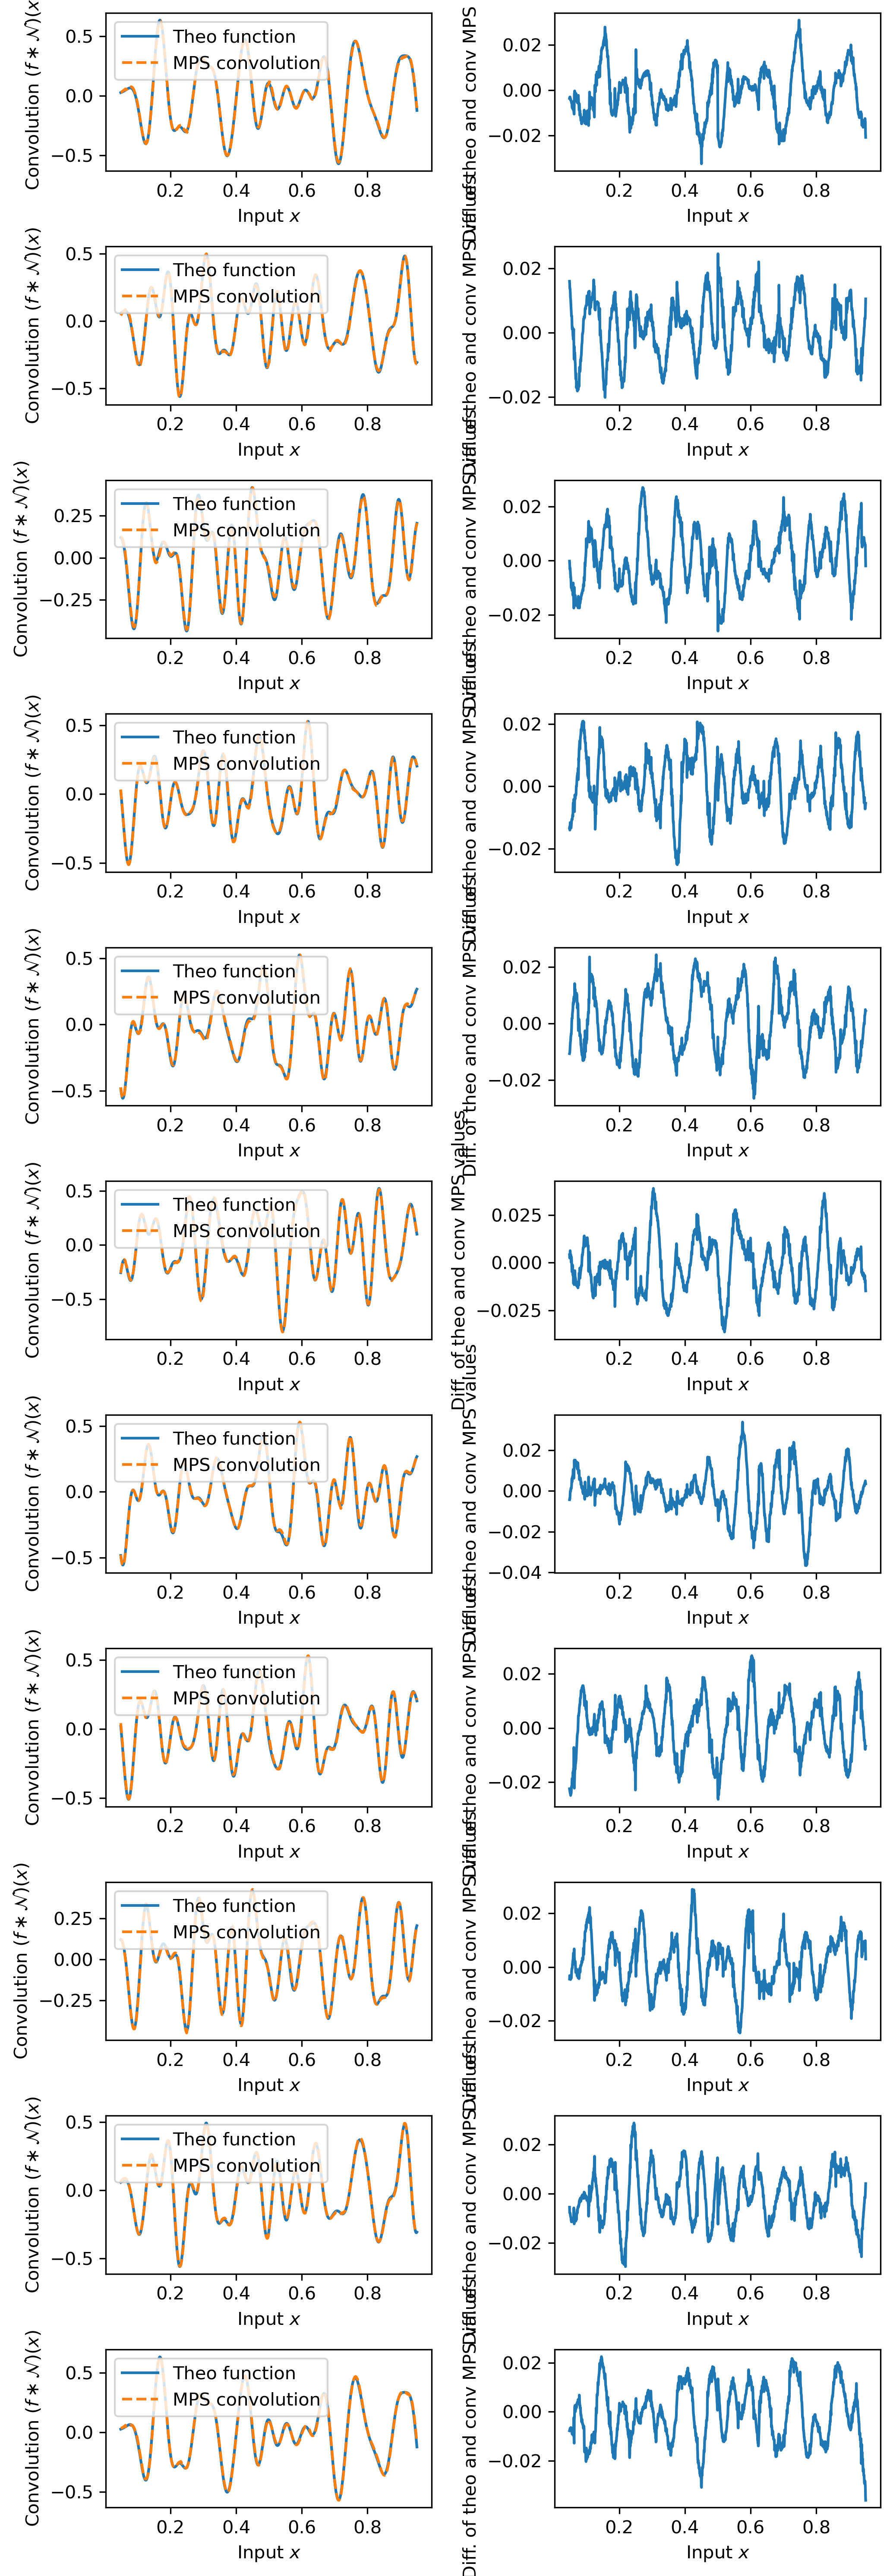

In [86]:
# Scegli l'indice spaziale/temporale da visualizzare nel plot
_, idxs = func_vals_theo.shape

# Plot comparison
fig, axs = plt.subplots(nrows= idxs, ncols=2, figsize=(7,20*idx_to_plot), dpi=300)

for i in range(idxs):
    axs[i, 0].plot(xs[100:-100], func_vals_theo[100:-100, i], '-', label='Theo function')
    axs[i, 0].plot(xs[100:-100], conv_MPS_vals[100:-100, i], '--', label='MPS convolution')
    axs[i, 0].set(xlabel=r'Input $x$',
                  ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
    axs[i, 0].legend(loc='upper left')

    axs[i, 1].plot(xs[100:-100], func_vals_theo[100:-100, i] - conv_MPS_vals[100:-100, i], '-')
    axs[i, 1].set(xlabel=r'Input $x$',
            ylabel='Diff. of theo and conv MPS values')

plt.tight_layout()
plt.show()

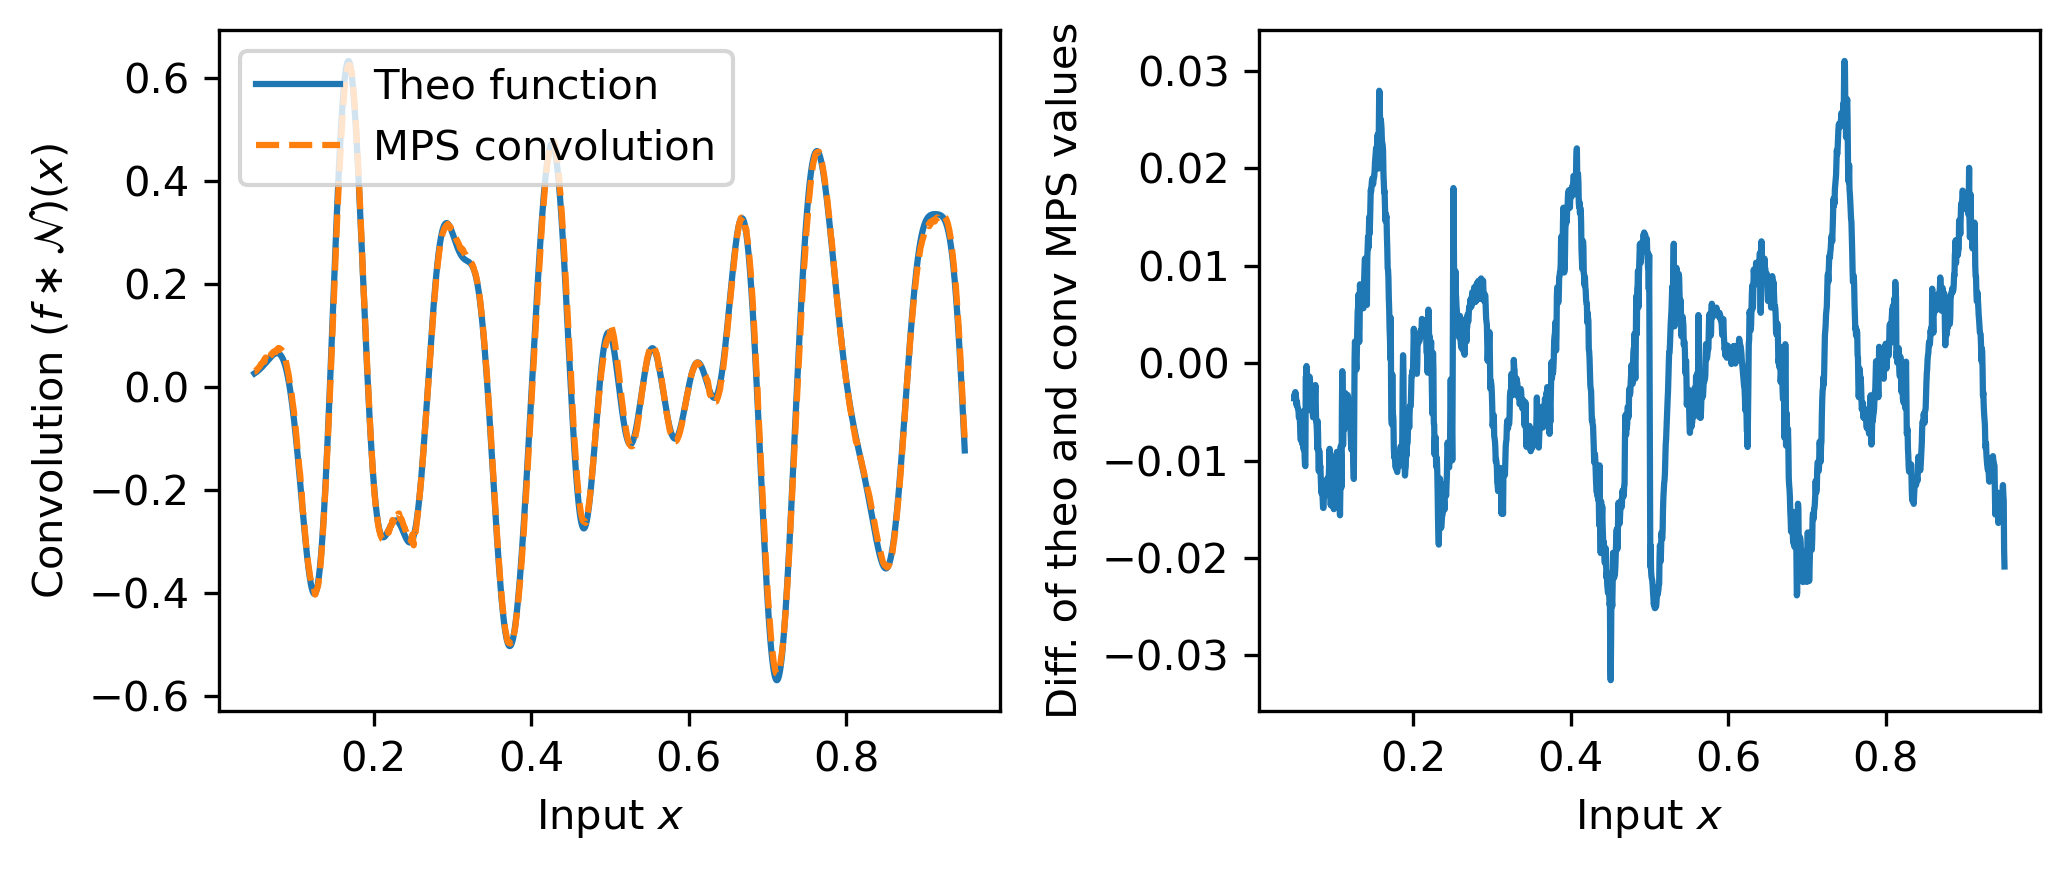

In [87]:
# Scegli l'indice spaziale/temporale da visualizzare nel plot
idx_to_plot = 0

# Plot comparison
fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)
axs[0].plot(xs[100:-100], func_vals_theo[100:-100, idx_to_plot], '-', label='Theo function')
axs[0].plot(xs[100:-100], conv_MPS_vals[100:-100, idx_to_plot], '--', label='MPS convolution')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
axs[0].legend(loc='upper left')

axs[1].plot(xs[100:-100], func_vals_theo[100:-100, idx_to_plot] - conv_MPS_vals[100:-100, idx_to_plot], '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of theo and conv MPS values')

plt.tight_layout()
plt.show()

In [88]:
print(func_vals_theo.shape)
print(conv_func_interp.shape)
print(conv_MPS_vals.shape)

(2048, 11)
(2048, 11)
(2048, 11)


In [89]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo, truncate_array_1 = 100, truncate_array_2 = -100)
err_max_conv_noise, err_2_conv_noise = MPS.errors(conv_MPS_vals, func_vals_noise, interpolate=False, truncate_array_1 = 100, truncate_array_2 = -100)
err_max_conv_theo, err_2_conv_theo = MPS.errors(conv_MPS_vals, func_vals_theo, interpolate=False, truncate_array_1 = 100, truncate_array_2 = -100)

In [90]:
print("Max error vs theo function (tci vs MPS conv): ", f"{err_max_theo:.4f}", f"{err_max_conv_theo:.4f}")
print("2-norm error vs theo function (tci vs MPS conv): ", f"{err_2_theo:.4f}", f"{err_2_conv_theo:.4f}")
print()
print("Max error vs noisy function (tci vs MPS conv): ", f"{err_max:.4f}", f"{err_max_conv_noise:.4f}")
print("2-norm error vs noisy function (tci vs MPS conv): ", f"{err_2:.4f}", f"{err_2_conv_noise:.4f}")

Max error vs theo function (tci vs MPS conv):  0.0537 0.0521
2-norm error vs theo function (tci vs MPS conv):  0.0317 0.0464

Max error vs noisy function (tci vs MPS conv):  0.0562 0.0826
2-norm error vs noisy function (tci vs MPS conv):  0.0540 0.0649


In [91]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo, truncate_array_1 = 200, truncate_array_2 = -200)
err_2_conv_theo_list = []

for entries in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    for sigmas in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]:
        peak = get_gaussian_peak(entries, sigma_factor=sigmas)

        len_peak = len(peak)

        full_peak = np.zeros(2**n)
        for i in range(len_peak):
            idx = 2**(n-1) - len_peak//2 + i
            full_peak[idx] = peak[i]

        Gs = peakMPS.build_peak_mps(n, peak)
        Ws = construct_convolution_MPO(L, conv_MPS = Gs)
        conv_As = apply_MPO(Ws, As)
        conv_MPS_vals = MPS.interpolate_func(conv_As)

        err_max_conv_noise, err_2_conv_noise = MPS.errors(conv_MPS_vals, func_vals_noise, interpolate=False, truncate_array_1 = 200, truncate_array_2 = -200)
        err_max_conv_theo, err_2_conv_theo = MPS.errors(conv_MPS_vals, func_vals_theo, interpolate=False, truncate_array_1 = 200, truncate_array_2 = -200)

        err_2_conv_theo_list.append([entries, sigmas, err_2_conv_theo])

        # if err_max_conv_theo < err_max_theo or err_2_conv_theo < err_2_theo:
        #     print(f"Better than TCI! Entries: {entries}, Sigma factor: {sigmas}")
        #     print("Max error vs theo function (tci vs MPS conv): ", f"{err_max_theo:.4f}", f"{err_max_conv_theo:.4f}")
        #     print("2-norm error vs theo function (tci vs MPS conv): ", f"{err_2_theo:.4f}", f"{err_2_conv_theo:.4f}")
        #     print()
        #     print("Max error vs noisy function (tci vs MPS conv): ", f"{err_max:.4f}", f"{err_max_conv_noise:.4f}")
        #     print("2-norm error vs noisy function (tci vs MPS conv): ", f"{err_2:.4f}", f"{err_2_conv_noise:.4f}")
        #     print("-------------------------------")
        #     print()
        # elif  err_max_conv_theo < 0.05 or err_2_conv_theo < 0.04:
        #     print(f"Entries: {entries}, Sigma factor: {sigmas}")
        #     print("Max error vs theo function (tci vs MPS conv): ", f"{err_max_theo:.4f}", f"{err_max_conv_theo:.4f}")
        #     print("2-norm error vs theo function (tci vs MPS conv): ", f"{err_2_theo:.4f}", f"{err_2_conv_theo:.4f}")
        #     print()
        #     print("Max error vs noisy function (tci vs MPS conv): ", f"{err_max:.4f}", f"{err_max_conv_noise:.4f}")
        #     print("2-norm error vs noisy function (tci vs MPS conv): ", f"{err_2:.4f}", f"{err_2_conv_noise:.4f}")
        #     print("-------------------------------")
        #     print()
        
    

In [92]:
err_2_conv_theo_arr = np.array(err_2_conv_theo_list)


In [93]:
index = np.argmin(err_2_conv_theo_arr[:, 2])
best_entries, best_sigmas, best_err_2_conv_theo = err_2_conv_theo_arr[index]
print(f"Best parameters: Entries = {best_entries}, Sigma factor = {best_sigmas}, 2-norm error vs theo function = {best_err_2_conv_theo:.4f}")

Best parameters: Entries = 8.0, Sigma factor = 4.0, 2-norm error vs theo function = 0.0352


In [94]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo, truncate_array_1 = 200, truncate_array_2 = -200)
err_2_conv_theo_list = []

for entries in [2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    for polyorder in [2,3,4,5]:
        if polyorder >= entries:
            continue
        peak = get_savgol_peak(window_length=entries, polyorder=polyorder)

        len_peak = len(peak)

        full_peak = np.zeros(2**n)
        for i in range(len_peak):
            idx = 2**(n-1) - len_peak//2 + i
            full_peak[idx] = peak[i]

        Gs = peakMPS.build_peak_mps(n, peak)
        Ws = construct_convolution_MPO(L, conv_MPS = Gs)
        conv_As = apply_MPO(Ws, As)
        conv_MPS_vals = MPS.interpolate_func(conv_As)

        err_max_conv_noise, err_2_conv_noise = MPS.errors(conv_MPS_vals, func_vals_noise, interpolate=False, truncate_array_1 = 200, truncate_array_2 = -200)
        err_max_conv_theo, err_2_conv_theo = MPS.errors(conv_MPS_vals, func_vals_theo, interpolate=False, truncate_array_1 = 200, truncate_array_2 = -200)

        err_2_conv_theo_list.append([entries, polyorder, err_2_conv_theo])
    

In [95]:
err_2_conv_theo_arr = np.array(err_2_conv_theo_list)


In [96]:
index = np.argmin(err_2_conv_theo_arr[:, 2])
best_entries, best_polyorder, best_err_2_conv_theo = err_2_conv_theo_arr[index]
print(f"Best parameters: Entries = {best_entries}, Polyorder = {best_polyorder}, 2-norm error vs theo function = {best_err_2_conv_theo:.4f} vs TCI error = {err_2_theo:.4f}")

Best parameters: Entries = 14.0, Polyorder = 2.0, 2-norm error vs theo function = 0.0352 vs TCI error = 0.0319
